# Part 2 - Copula-Based Dependence Modelling

Part 1 extracted, for each of the five assets, the risk-neutral marginal distribution $F_k$ implied by the options market. However, knowing each asset's individual distribution says nothing about how the assets move together. To price a basket option we need to simulate all five assets jointly, which requires specifying a dependence structure.  

We use a copula to model this dependece. By Sklar's theorem, any joint distribution can be decomposed as  $$F_{1,...,5}​(x_1​,...,x_5​)=C(F_1​(x_1​),...,F_5​(x_5​))$$ where $ C : [0,1]^5 \to [0,1]$ is the copula: a joint distribution on uniform random variables that encodes only the dependece, completely separated from the marginals. This separation allows us to pair the realistic, market-implied marginals from Part 1 with any dependence structure we choose to assume. 

As a first choice of dependence structure, we implement the Gaussian copula, which assumes that the dependence between assets follows the same structure as a multivariate normal distribution with correlation matrix $R$.

To estimate R, we download one year of daily adjusted closing prices for the five assets.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copula import estimate_correlation, build_inverse_cdf, sample_gaussian_copula

tickers = ["NVDA", "PLTR", "MSFT", "STX", "GOOGL"]
df = pd.read_csv("marginal_dist.csv")

The heatmap below displays the pairwise correlations between the five assets, with values annotated for clarity.


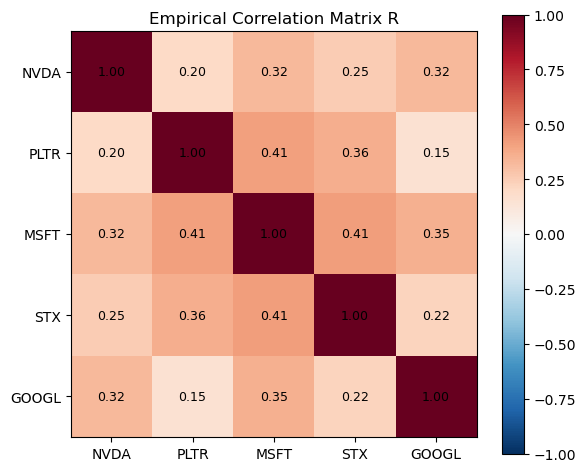

In [14]:
R = estimate_correlation(tickers)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(tickers))); ax.set_xticklabels(tickers)
ax.set_yticks(range(len(tickers))); ax.set_yticklabels(tickers)
plt.colorbar(im, ax=ax)
ax.set_title("Empirical Correlation Matrix R")
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{R[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Before sampling from the copula, we build the inverse CDF $F_k^{-1}$ for each asset by interpolating the discrete $(K, \text{cdf})$ table produced in Part 1. This allows us to map any uniform sample $U_k \in [0,1]$ back to an asset price $S_k = F_k^{-1}(U_k)$

In [15]:
inv_cdfs = []
for ticker in tickers:
    asset = df[df["ticker"] == ticker]
    K_grid = asset["K"].values
    cdf    = asset["cdf"].values
    inv_cdfs.append(build_inverse_cdf(K_grid, cdf))

We now sample $n_{sim} = 10{,}000$ joint outcomes from the Gaussian copula. Following the algorithm from Choi (2026, M9): 
- we generate independent standard normals
- correlate them via Cholesky decomposition of $R$, 
- transform to uniforms $U_k = N(Z'_k)$, 
- and finally recover asset prices via $S_k = F_k^{-1}(U_k)$.

In [16]:
n_sim = 10_000
S, U = sample_gaussian_copula(R, inv_cdfs, n_sim)

We validate the dependence structure by plotting the uniform copula samples $U_i$ against $U_j$ for five representative pairs of assets. Under the Gaussian copula, these scatter plots should show an elliptical dependence structure: concentrated along the diagonal for highly correlated pairs, and more spread out for less correlated ones. Crucially, the corners of each plot should be relatively empty, reflecting the absence of tail dependence in the Gaussian copula.

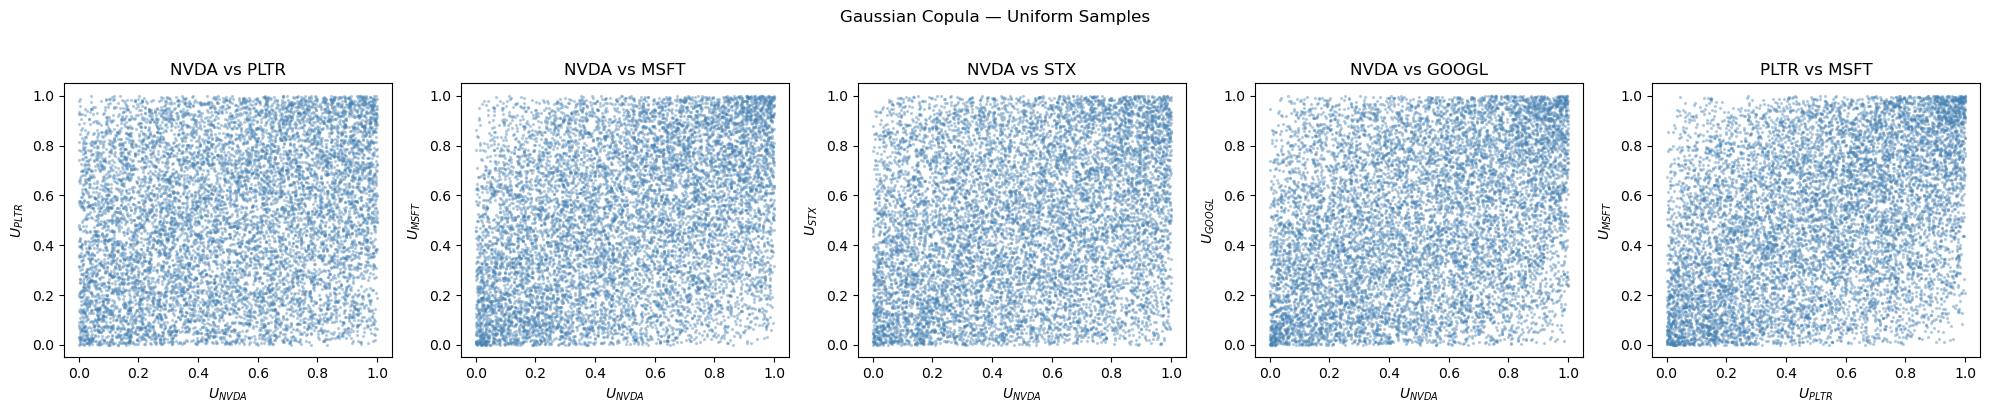

In [17]:
pairs = [(0,1), (0,2), (0,3), (0,4), (1,2)]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(U[:, i], U[:, j], s=2, alpha=0.3, color="steelblue")
    ax.set_xlabel(f"$U_{{{tickers[i]}}}$")
    ax.set_ylabel(f"$U_{{{tickers[j]}}}$")
    ax.set_title(f"{tickers[i]} vs {tickers[j]}")
plt.suptitle("Gaussian Copula — Uniform Samples", y=1.02)
plt.tight_layout()
plt.show()


Finally, we verify that the marginal distributions are correctly preserved. For each asset, we overlay the histogram of simulated terminal prices against the risk-neutral density extracted in Part 1. If the copula implementation is correct, the two should match closely, confirming that the Gaussian copula has introduced dependence between assets without distorting their individual distributions.

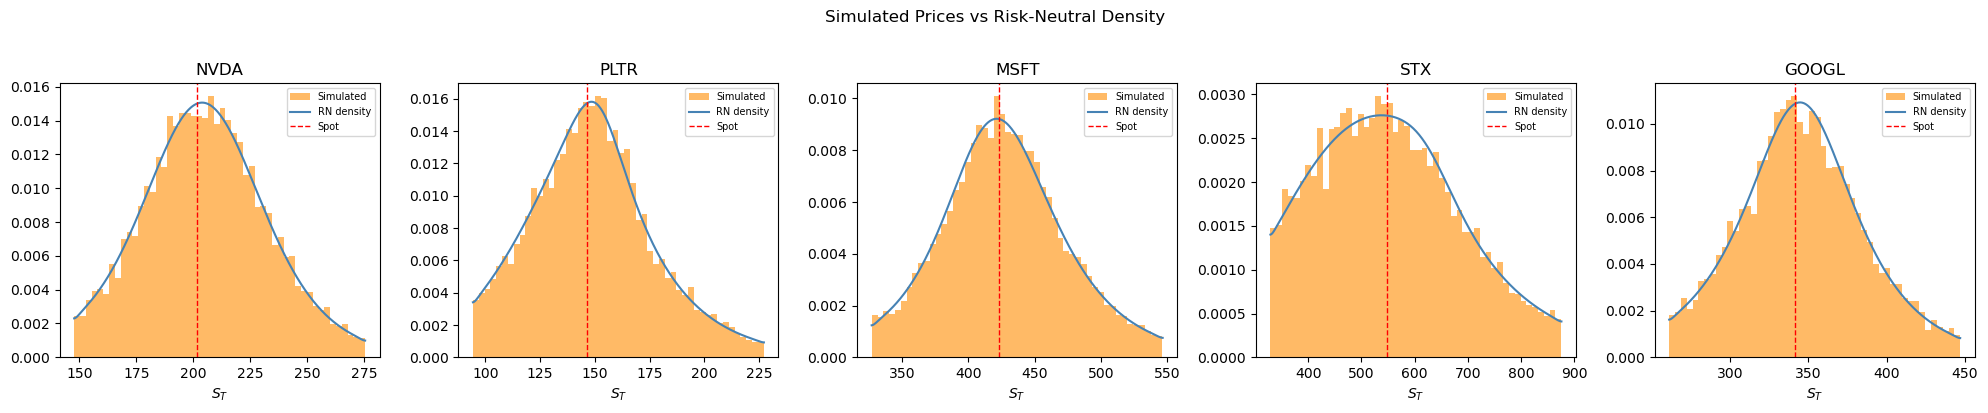

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ticker in enumerate(tickers):
    asset = df[df["ticker"] == ticker]
    axes[i].hist(S[:, i], bins=50, density=True,
                 color="darkorange", alpha=0.6, label="Simulated")
    axes[i].plot(asset["K"].values, asset["pdf"].values,
                 color="steelblue", lw=1.5, label="RN density")
    axes[i].axvline(asset["S"].iloc[0], color="red", lw=1,
                    linestyle="--", label="Spot")
    axes[i].set_title(f"{ticker}")
    axes[i].set_xlabel("$S_T$")
    axes[i].legend(fontsize=7)
plt.suptitle("Simulated Prices vs Risk-Neutral Density", y=1.02)
plt.tight_layout()
plt.show()

While the Gaussian copula provides a simple and tractable way to model dependence, it has a well-known limitation: it implies no tail dependence. This means that in the Gaussian copula framework, extreme co-movements become asymptotically independent. This is an unrealistic assumption for equity markets, where joint crashes are well-documented empirically.

To address this, we implement the Student-t copula, which introduces tail dependence by borrowing its dependence structure from a multivariate Student-t distribution with $\nu$
degrees of freedom. The key difference from the Gaussian copula is the introduction of a shared random variable $V \sim \chi^2(\nu)$ that scales all assets simultaneously, creating the possibility of joint extreme events. 

The parameter $\nu$ controls the strength of this tail dependence: smaller values of $\nu$ imply heavier tails and stronger co-movements in the extremes, while as $\nu \to \infty$ the Student-t copula converges to the Gaussian copula.

To select $\nu$, we estimate it from historical data by maximum likelihood. We first transform the historical log-returns of each asset into pseudo-observations, their empirical ranks scaled to $[0,1]$, which isolates the dependence structure from the marginals. We then maximize the log-likelihood of the Student-t copula over $\nu$, using the correlation matrix $R$ already estimated in the Gaussian copula step.

In [19]:
from copula import estimate_nu, sample_student_copula

We first estimate the degrees of freedom parameter nu by maximum likelihood. The value of nu directly controls the strength of tail dependence. We print it to interpret how heavy-tailed the estimated dependence structure is.

In [20]:
nu = estimate_nu(tickers, R)
print(f"Estimated degrees of freedom: nu = {nu:.2f}")

Estimated degrees of freedom: nu = 9.64


We now sample 10,000 joint outcomes from the Student-t copula using the estimated nu and the same correlation matrix R from the Gaussian copula step.


In [21]:
S_t, U_t = sample_student_copula(R, nu, inv_cdfs, n_sim)

We validate the dependence structure by plotting the uniform copula samples for the same five pairs as before. Compared to the Gaussian copula, the Student-t scatter plots should show points more concentrated in the corners, reflecting the tail dependence introduced by the shared chi-squared variable.


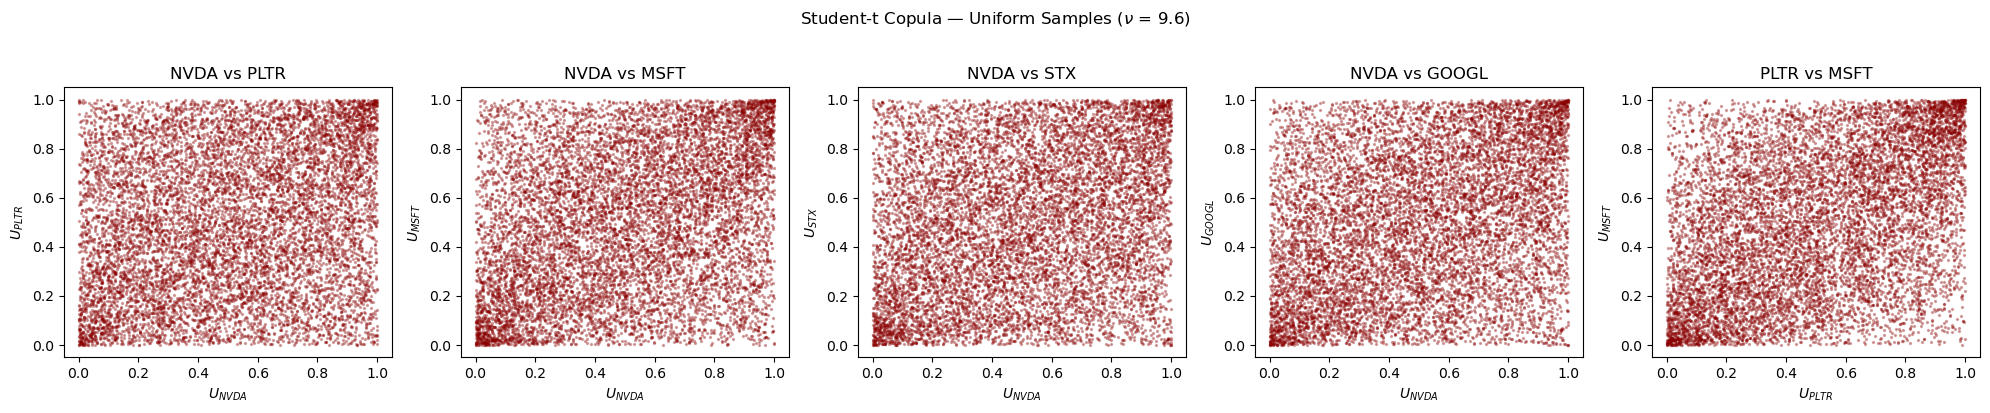

In [22]:
pairs = [(0,1), (0,2), (0,3), (0,4), (1,2)]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(U_t[:, i], U_t[:, j], s=2, alpha=0.3, color="darkred")
    ax.set_xlabel(f"$U_{{{tickers[i]}}}$")
    ax.set_ylabel(f"$U_{{{tickers[j]}}}$")
    ax.set_title(f"{tickers[i]} vs {tickers[j]}")
plt.suptitle(f"Student-t Copula — Uniform Samples ($\\nu$ = {nu:.1f})", y=1.02)
plt.tight_layout()
plt.show()

As before, we verify that the marginal distributions are correctly preserved. The simulated price histograms should match the risk-neutral densities from Part 1 closely, confirming that the Student-t copula has introduced tail dependence without distorting the individual asset distributions.


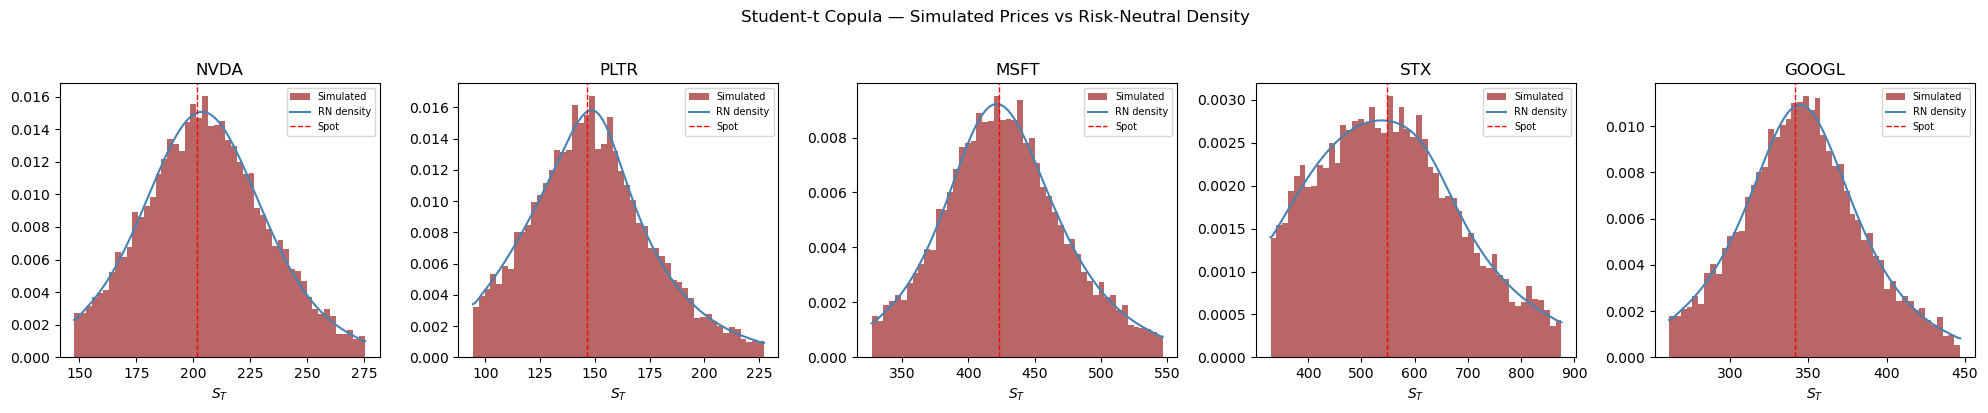

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ticker in enumerate(tickers):
    asset = df[df["ticker"] == ticker]
    axes[i].hist(S_t[:, i], bins=50, density=True,
                 color="darkred", alpha=0.6, label="Simulated")
    axes[i].plot(asset["K"].values, asset["pdf"].values,
                 color="steelblue", lw=1.5, label="RN density")
    axes[i].axvline(asset["S"].iloc[0], color="red", lw=1,
                    linestyle="--", label="Spot")
    axes[i].set_title(f"{ticker}")
    axes[i].set_xlabel("$S_T$")
    axes[i].legend(fontsize=7)
plt.suptitle("Student-t Copula — Simulated Prices vs Risk-Neutral Density", y=1.02)
plt.tight_layout()
plt.show()


Finally, we directly compare the Gaussian and Student-t copula scatter plots side by side for the NVDA vs MSFT pair, the most correlated pair in our basket. This highlights the key difference between the two copulas: the Student-t produces more points in the corners (joint extremes), while the Gaussian is more uniformly spread.

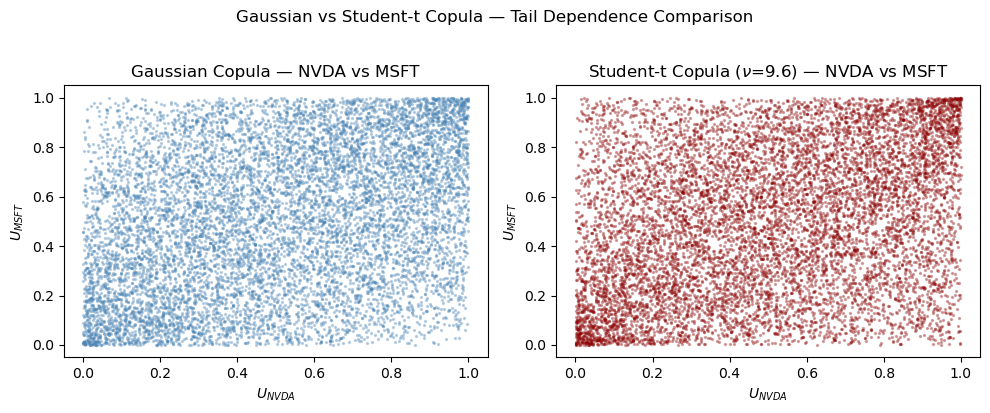

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(U[:, 0], U[:, 2], s=2, alpha=0.3, color="steelblue")
axes[0].set_title(f"Gaussian Copula — NVDA vs MSFT")
axes[0].set_xlabel("$U_{NVDA}$"); axes[0].set_ylabel("$U_{MSFT}$")

axes[1].scatter(U_t[:, 0], U_t[:, 2], s=2, alpha=0.3, color="darkred")
axes[1].set_title(f"Student-t Copula ($\\nu$={nu:.1f}) — NVDA vs MSFT")
axes[1].set_xlabel("$U_{NVDA}$"); axes[1].set_ylabel("$U_{MSFT}$")

plt.suptitle("Gaussian vs Student-t Copula — Tail Dependence Comparison", y=1.02)
plt.tight_layout()
plt.show()

We save the simulated asset prices from notj compulas to CSV files for use in the next phase of the project. Each file contains 10,000 rows (one per simulation) and 5 columns (one per asset), with column names corresponding to the tickers.

In [27]:
# Gaussian copula output
pd.DataFrame(S, columns=tickers).to_csv("simulated_prices_gaussian.csv", index=False)

# Student-t copula output
pd.DataFrame(S_t, columns=tickers).to_csv("simulated_prices_student.csv", index=False)

# Metadata needed by Part 3
meta = {
    "tickers": tickers,
    "spot":    [df[df["ticker"] == t]["S"].iloc[0] for t in tickers],
    "T":       float(df["T"].iloc[0]),
    "nu":      float(nu)
}
pd.DataFrame(meta).to_csv("copula_meta.csv", index=False)